In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# load prepared data from data_processing.ipynb
filename = "../gb_energy_data.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PRICE

To be able to compare exogenous models the data cannot contain missing values. Therfore, the missing values will be replaced by estimates of the latent state using a state-space model (ARIMA) and the kalman filter. The Kalman filter is automatically applied by the SARIMAX function. 

To find an appropriate model, use the auto_arima function from pmdarima, which does not handle missing values natively. So, first replace missing values using the 'interpolate' function and compares ARIMA models on a small subset of the the data (otherwise the machine crashes). Indepently fit a model to day-ahead prices, wind generation and solar generation. Use the appropriate fitted values to fill the missing data. 
Models appear to have a much better fit when using the logged data, which removes the possibility of negative values. Although negative values are possible and do ocassionaly arise in energy prices, the model appeared to over anticipate this. 

The auto_arima function fits models with differing orders for seasonal ARIMA models and we compare them using the model's AIC. 


In [2]:
data_gb['log1p_price_day_ahead'] = np.log1p(data_gb['GB_GBN_price_day_ahead'])

/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'log Day-Ahead Energy Price')

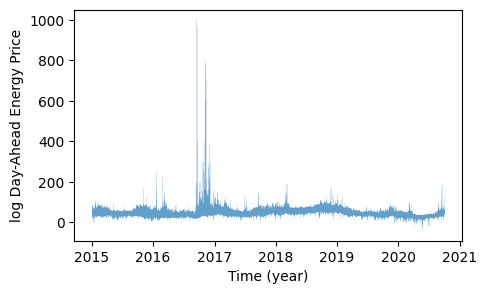

In [4]:
fig, axes = plt.subplots(1, figsize=(5, 3))
axes.plot(data_gb.index, data_gb['GB_GBN_price_day_ahead'], alpha=0.7, linewidth=0.1)
axes.set_xlabel('Time (year)')
axes.set_ylabel('log Day-Ahead Energy Price')

In [12]:
data_gb[ data_gb['GB_GBN_price_day_ahead']== 0.0]

,GB_GBN_price_day_ahead,GB_GBN_solar_generation_actual,GB_GBN_wind_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,log1p_price_day_ahead
utc_timestamp,,,,,,
2015-01-10 23:00:00+00:00,0.0,0.0,6706.0,34996.0,32512.0,0.0
2015-01-11 00:00:00+00:00,0.0,0.0,6433.0,32823.0,31010.0,0.0
2015-01-11 01:00:00+00:00,0.0,0.0,6306.0,32474.0,30112.0,0.0
2015-01-11 02:00:00+00:00,0.0,0.0,6269.0,30176.0,28914.0,0.0
2015-01-11 03:00:00+00:00,0.0,0.0,6262.0,28533.0,27562.0,0.0
2015-01-11 04:00:00+00:00,0.0,0.0,6232.0,26665.0,26596.0,0.0
2015-01-11 05:00:00+00:00,0.0,0.0,6200.0,26001.0,26436.0,0.0
2015-01-11 06:00:00+00:00,0.0,0.0,6230.0,26581.0,27418.0,0.0
2015-01-11 07:00:00+00:00,0.0,0.0,6256.0,28847.0,28546.0,0.0


Text(0, 0.5, 'log Day-Ahead Energy Price')

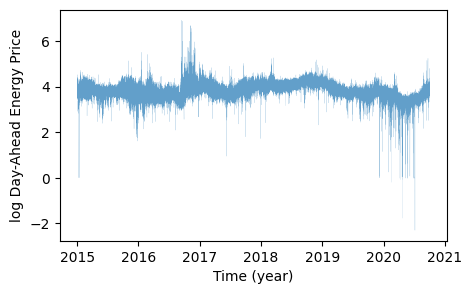

In [7]:
fig, axes = plt.subplots(1, figsize=(5, 3))
axes.plot(data_gb.index, data_gb['log1p_price_day_ahead'], alpha=0.7, linewidth=0.1)
axes.set_xlabel('Time (year)')
axes.set_ylabel('log Day-Ahead Energy Price')

In [16]:
log_day_ahead_prices_interpolated = data_gb["log1p_price_day_ahead"].interpolate(method="time")

log_price_models = auto_arima(
    log_day_ahead_prices_interpolated.iloc[-(100*24):],  # smaller sample first,
    seasonal=True,
    m=24,
    stepwise=True,
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=2,
    max_d=2,
    max_D=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print( log_price_models.summary())
print( log_price_models.aic() )
print( log_price_models.order )
print( log_price_models.seasonal_order )

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=7.53 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=-727.862, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=-881.641, Time=0.98 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=-849.849, Time=1.31 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=-729.860, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=-768.080, Time=0.19 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=-936.057, Time=8.00 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=22.81 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=4.59 sec
 ARIMA(0,1,0)(2,0,0)[24] intercept   : AIC=-936.275, Time=5.15 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=-878.815, Time=0.82 sec
 ARIMA(0,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=18.59 sec
 ARIMA(0,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=4.03 sec
 ARIMA(0,1,1)(2,0,0)[24] intercept   : AIC=-935.618, Time=7.34 sec
 ARIMA(1,1,1)(2,0,0)[24] intercept   : AIC

In [17]:
price_order = log_price_models.order
price_seasonal_order = log_price_models.seasonal_order

In [6]:
if False:
    price_order = (2,1,2)
    price_seasonal_order = (2,0,0,24)

Now, fit the model with appropriate orders using the whole dataset (on the log+1 scale) using the SARIMAX funciton. This automatically handles missing values and estimates them using the Kalman filter. Once this is done, add a column to the dataframe where missing values have been replaced by their estimates and compare to the actual data using a time series plot. 

In [18]:
# fit the ARMIA model to the data and find the fitted values to replace the 

model_log_price_filler = SARIMAX(
    data_gb['log1p_price_day_ahead'],
    order=price_order,
    seasonal_order = price_seasonal_order
)

log_price_result = model_log_price_filler.fit(disp=False)
price_fitted_values = np.expm1(log_price_result.fittedvalues)

/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


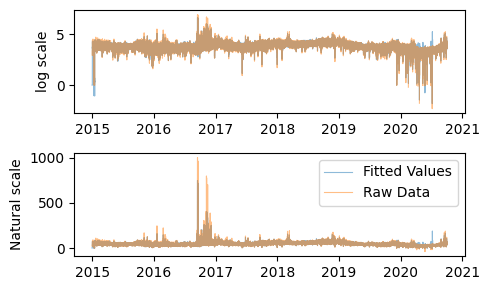

In [19]:
# sanity check: plot fitted values against observed data

fig, axes = plt.subplots(2, 1, figsize=(5,3), sharex=False)
# log-scale
axes[0].plot(log_price_result.fittedvalues.index, log_price_result.fittedvalues,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[0].plot(data_gb.index, np.log1p(data_gb.GB_GBN_price_day_ahead), linewidth=0.8, label='Raw Data', alpha=0.5)
axes[0].set_ylabel("log scale")
# natural scale
axes[1].plot(price_fitted_values.index, price_fitted_values,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[1].plot(data_gb.index, data_gb.GB_GBN_price_day_ahead, linewidth=0.8, label='Raw Data', alpha=0.5)
axes[1].legend()
axes[1].set_ylabel("Natural scale")
plt.tight_layout()
plt.show()

In [20]:
# add columb to the dataframe
data_gb['price_day_ahead_filled'] = data_gb['GB_GBN_price_day_ahead'].fillna(price_fitted_values)
data_gb['log1p_price_day_ahead'] = np.log1p(data_gb['GB_GBN_price_day_ahead'])
data_gb['log1p_price_day_ahead_filled'] = data_gb['log1p_price_day_ahead'].fillna(log_price_result.fittedvalues)


In [ ]:
data_gb.to_csv('../gb_energy_price_filled.csv')

# Estimate missing values in the solar generation

Repeat the same steps as before but using the solar-generation data. 

In [3]:
data_gb['log1p_solar_generation'] = np.log1p(data_gb['GB_GBN_solar_generation_actual'])

In [4]:
log_solar_generation_interpolated = data_gb["log1p_solar_generation"].interpolate(method="time")

log_solar_models = auto_arima(
    log_solar_generation_interpolated.iloc[-(100*24):],  # smaller sample first,
    seasonal=True,
    m=24,
    stepwise=True,
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=2,
    max_d=2,
    max_D=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

# print(log_solar_models.summary())
print( log_solar_models.aic() )
print( log_solar_models.order )
print( log_solar_models.seasonal_order )

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=1717.243, Time=7.63 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=8183.888, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=2.67 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=5990.296, Time=0.97 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=8181.894, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=5887.264, Time=2.10 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=2406.627, Time=7.91 sec
 ARIMA(2,1,2)(2,0,1)[24] intercept   : AIC=1698.006, Time=33.98 sec
 ARIMA(2,1,2)(2,0,0)[24] intercept   : AIC=1819.272, Time=30.41 sec
 ARIMA(2,1,2)(2,0,2)[24] intercept   : AIC=1658.398, Time=18.72 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=1662.180, Time=17.05 sec
 ARIMA(1,1,2)(2,0,2)[24] intercept   : AIC=inf, Time=18.74 sec
 ARIMA(2,1,1)(2,0,2)[24] intercept   : AIC=1644.547, Time=33.53 sec
 ARIMA(2,1,1)(1,0,2)[24] intercept   : AIC=1647.578, Time=29.59 sec
 ARIMA(2,1,1)(2,0,1)[2

In [5]:
# The model which minimizes AIC is the SARIMA(1,1,2)(2,0,2)[24]
# fit the ARMIA model to the data and find the fitted values to replace the 
model_log_solar_filler = SARIMAX(
    data_gb['log1p_solar_generation'],
    order=(1,1,2),
    seasonal_order = (2,0,2,24)
)
log_solar_result = model_log_solar_filler.fit(disp=False)
solar_fitted_values = np.expm1(log_solar_result.fittedvalues)

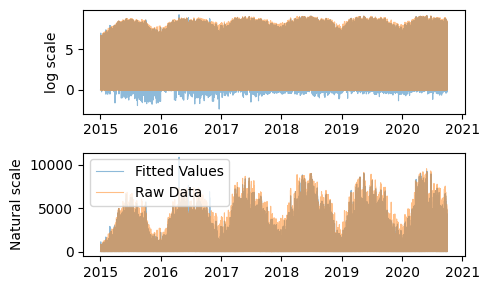

In [6]:
# Sanity check do the fitted values match the observed data
fig, axes = plt.subplots(2, 1, figsize=(5,3), sharex=False)
axes[0].plot(log_solar_result.fittedvalues.index, log_solar_result.fittedvalues,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[0].plot(data_gb.index, np.log1p(data_gb['GB_GBN_solar_generation_actual']), linewidth=0.8, label='Raw Data', alpha=0.5)
axes[0].set_ylabel("log scale")

axes[1].plot(solar_fitted_values.index, solar_fitted_values,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[1].plot(data_gb.index, data_gb['GB_GBN_solar_generation_actual'], linewidth=0.8, label='Raw Data', alpha=0.5)
axes[1].legend()
axes[1].set_ylabel("Natural scale")
plt.tight_layout()
plt.show()

In [7]:
data_gb['solar_generation_filled'] = data_gb['GB_GBN_solar_generation_actual'].fillna(solar_fitted_values)
data_gb['log1p_solar_generation'] = np.log1p(data_gb['GB_GBN_solar_generation_actual'])
data_gb['log1p_solar_generation_filled'] = data_gb['log1p_solar_generation'].fillna(log_solar_result.fittedvalues)


# Estimate missing values for wind generation

In [8]:
data_gb['log1p_wind_generation'] = np.log1p(data_gb['GB_GBN_wind_generation_actual'])
data_gb['log1p_wind_generation_lag1'] = data_gb['log1p_wind_generation'].shift(1)

In [9]:
log_wind_generation_interpolated = data_gb["log1p_wind_generation"].interpolate(method="time")

log_wind_models = auto_arima(
    log_wind_generation_interpolated.iloc[-(100*24):],  # smaller sample first,
    seasonal=True,
    m=24,
    stepwise=True,
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=2,
    max_d=2,
    max_D=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

# print(log_wind_models.summary())

print( log_wind_models.aic() )
print( log_wind_models.order )
print( log_wind_models.seasonal_order )

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=7.48 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=214.799, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=-57.835, Time=1.01 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=-63.530, Time=1.13 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=212.799, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=-63.632, Time=0.08 sec
 ARIMA(0,1,1)(1,0,0)[24] intercept   : AIC=-63.643, Time=1.02 sec
 ARIMA(0,1,1)(2,0,0)[24] intercept   : AIC=-64.005, Time=4.85 sec
 ARIMA(0,1,1)(2,0,1)[24] intercept   : AIC=inf, Time=19.35 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=inf, Time=3.79 sec
 ARIMA(0,1,0)(2,0,0)[24] intercept   : AIC=217.375, Time=1.95 sec
 ARIMA(1,1,1)(2,0,0)[24] intercept   : AIC=-71.318, Time=10.17 sec
 ARIMA(1,1,1)(1,0,0)[24] intercept   : AIC=-71.147, Time=1.96 sec
 ARIMA(1,1,1)(2,0,1)[24] intercept   : AIC=inf, Time=25.46 sec
 ARIMA(1,1,1)(1,0,1)[24] intercept   : AIC=inf

In [10]:
# The model which minimizes AIC is the SARIMA(1,1,2)(2,0,1)[24]
# fit the ARMIA model to the data and find the fitted values to replace the 

model_log_wind_filler = SARIMAX(
    data_gb['log1p_wind_generation'],
    order=(1,1,2),
    seasonal_order = (1,0,2,24)
)
log_wind_result = model_log_wind_filler.fit(disp=False)
wind_fitted_values = np.expm1(log_wind_result.fittedvalues)

/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


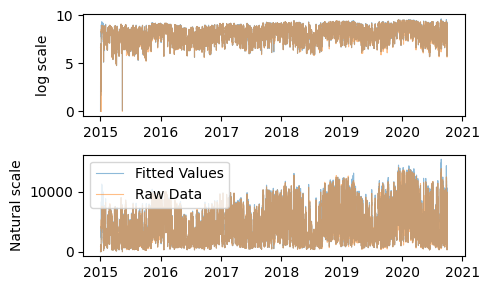

In [11]:
# Sanity check do the fitted values match the observed data
fig, axes = plt.subplots(2, 1, figsize=(5,3), sharex=False)
axes[0].plot(log_wind_result.fittedvalues.index, log_wind_result.fittedvalues,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[0].plot(data_gb.index, np.log1p(data_gb['GB_GBN_wind_generation_actual']), linewidth=0.8, label='Raw Data', alpha=0.5)
axes[0].set_ylabel("log scale")

axes[1].plot(wind_fitted_values.index, wind_fitted_values,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[1].plot(data_gb.index, data_gb['GB_GBN_wind_generation_actual'], linewidth=0.8, label='Raw Data', alpha=0.5)
axes[1].legend()
axes[1].set_ylabel("Natural scale")
plt.tight_layout()
plt.show()

In [12]:
# add the `filled` data to the data frame
data_gb['wind_generation_filled'] = data_gb['GB_GBN_wind_generation_actual'].fillna(wind_fitted_values)
data_gb['log1p_wind_generation'] = np.log1p(data_gb['GB_GBN_wind_generation_actual'])
data_gb['log1p_wind_generation_filled'] = data_gb['log1p_wind_generation'].fillna(log_wind_result.fittedvalues)

In [13]:
data_gb.to_csv('../gb_energy_price_solar_wind_filled.csv')

# DAY-AHEAD FORECAST

In [15]:
data_gb.columns

Index(['GB_GBN_price_day_ahead', 'GB_GBN_solar_generation_actual',
       'GB_GBN_wind_generation_actual',
       'GB_GBN_load_actual_entsoe_transparency',
       'GB_GBN_load_forecast_entsoe_transparency', 'log1p_solar_generation',
       'solar_generation_filled', 'log1p_solar_generation_filled',
       'log1p_wind_generation', 'log1p_wind_generation_lag1',
       'wind_generation_filled', 'log1p_wind_generation_filled'],
      dtype='str')

In [2]:
# load prepared data from data_processing.ipynb
filename = "../gb_energy_price_solar_wind_filled.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

In [3]:
data_gb['log1p_load_forecast'] = np.log1p(data_gb['GB_GBN_load_forecast_entsoe_transparency'])

log_load_forecast_interpolated = data_gb["log1p_load_forecast"].interpolate(method="time")

log_wind_models = auto_arima(
    log_load_forecast_interpolated.iloc[-(100*24):],  # smaller sample first,
    seasonal=True,
    m=24,
    stepwise=True,
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=2,
    max_d=2,
    max_D=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

# print(log_wind_models.summary())

print( log_wind_models.aic() )
print( log_wind_models.order )
print( log_wind_models.seasonal_order )

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=-13028.777, Time=8.31 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=-6459.285, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=3.03 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=-10259.978, Time=2.55 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=-6461.284, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=-11033.886, Time=6.67 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=-12429.373, Time=6.47 sec
 ARIMA(2,1,2)(2,0,1)[24] intercept   : AIC=-12975.227, Time=34.43 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=-13122.057, Time=17.95 sec
 ARIMA(2,1,2)(0,0,2)[24] intercept   : AIC=-11523.571, Time=15.50 sec
 ARIMA(2,1,2)(2,0,2)[24] intercept   : AIC=inf, Time=19.13 sec
 ARIMA(1,1,2)(1,0,2)[24] intercept   : AIC=-13079.074, Time=16.01 sec
 ARIMA(2,1,1)(1,0,2)[24] intercept   : AIC=inf, Time=14.75 sec
 ARIMA(1,1,1)(1,0,2)[24] intercept   : AIC=-13087.065, Time=27.57 sec
 ARIMA(

In [4]:
# The model which minimizes AIC is the SARIMA(2,1,0)(1,0,2)[24]
# fit the ARMIA model to the data and find the fitted values to replace the 

model_log_load_filler = SARIMAX(
    data_gb['log1p_load_forecast'],
    order=(2,1,0),
    seasonal_order = (1,0,2,24)
)
log_load_forecast_result = model_log_load_filler.fit(disp=False)
load_fitted_values = np.expm1(log_load_forecast_result.fittedvalues)

/Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


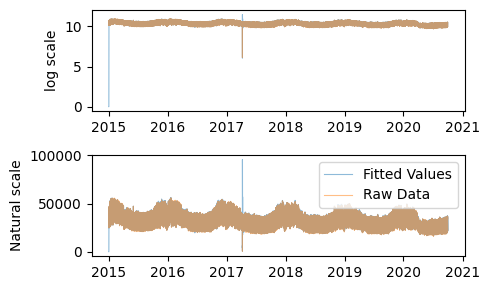

In [5]:
# Sanity check do the fitted values match the observed data
fig, axes = plt.subplots(2, 1, figsize=(5,3), sharex=False)

axes[0].plot(log_load_forecast_result.fittedvalues.index, log_load_forecast_result.fittedvalues,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[0].plot(data_gb.index, np.log1p(data_gb['GB_GBN_load_forecast_entsoe_transparency']), linewidth=0.8, label='Raw Data', alpha=0.5)
axes[0].set_ylabel("log scale")

axes[1].plot(load_fitted_values.index, load_fitted_values,linewidth=0.8, label='Fitted Values', alpha=0.5)
axes[1].plot(data_gb.index, data_gb['GB_GBN_load_forecast_entsoe_transparency'], linewidth=0.8, label='Raw Data', alpha=0.5)
axes[1].legend()
axes[1].set_ylabel("Natural scale")
plt.tight_layout()
plt.show()

In [6]:
# add the `filled` data to the data frame
data_gb['load_forecast_filled'] = data_gb['GB_GBN_load_forecast_entsoe_transparency'].fillna(load_fitted_values)
data_gb['log1p_load_forecast'] = np.log1p(data_gb['GB_GBN_load_forecast_entsoe_transparency'])
data_gb['log1p_load_forecast_filled'] = data_gb['log1p_load_forecast'].fillna(log_load_forecast_result.fittedvalues)

# Add Saturday and Sunday variable

In [8]:
data_gb['is_saturday'] = (data_gb.index.weekday == 5).astype(int)
data_gb['is_sunday'] = (data_gb.index.weekday == 6).astype(int)

# Save data frame with filled values

In [7]:
# save dataframe
data_gb.to_csv('../gb_energy_data_filled.csv')

# Some checks n stuff

In [3]:
# load prepared data from data_processing.ipynb
filename = "../gb_energy_data_filled.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()

/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_59630/3390300273.py:3: DtypeWarning: Columns (0: Unnamed: 0, 1: utc_timestamp) have mixed types. Specify dtype option on import or set low_memory=False.
  data_gb = pd.read_csv(filename)


In [8]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, signif=0.05, name='', verbose=False):
    result = adfuller(series.values)
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

In [11]:
data_gb.columns

Index(['GB_GBN_price_day_ahead', 'GB_GBN_solar_generation_actual',
       'GB_GBN_wind_generation_actual',
       'GB_GBN_load_actual_entsoe_transparency',
       'GB_GBN_load_forecast_entsoe_transparency', 'log1p_solar_generation',
       'solar_generation_filled', 'log1p_solar_generation_filled',
       'log1p_wind_generation', 'log1p_wind_generation_lag1',
       'wind_generation_filled', 'log1p_wind_generation_filled',
       'log1p_load_forecast', 'load_forecast_filled',
       'log1p_load_forecast_filled'],
      dtype='str')

In [13]:
log_features = ['log1p_price_day_ahead_filled', 'log1p_solar_generation_filled', 'log1p_wind_generation_filled', 'log1p_load_forecast_filled']

for feature in log_features:
    check_stationarity(data_gb[feature])

KeyError: 'log1p_price_day_ahead_filled'